# **FRENCH INDUSTRY 1**
## Data cleaning, Pre-Processing et Premières Visualisations

#### Janyce, Maimouna, Eric, Loris

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
df_salary = pd.read_csv('net_salary_per_town_categories.csv')
df_geo = pd.read_csv("name_geographic_information.csv")
df_effectif = pd.read_csv("base_etablissement_par_tranche_effectif.csv")
df_population = pd.read_csv('population.csv')



/var/folders/7k/1gss3s8n3ks5v614tjxzcb2w0000gn/T/ipykernel_3931/3219805365.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_population = pd.read_csv('population.csv')


## **1 - Data Cleaning, Pré-Processing**

###  **1.1 - Dataset Salary**


In [ ]:
# Affichage du dataset

df_salary.head()

,CODGEO,LIBGEO,SNHM14,SNHMC14,SNHMP14,SNHME14,SNHMO14,SNHMF14,SNHMFC14,SNHMFP14,...,SNHMHO14,SNHM1814,SNHM2614,SNHM5014,SNHMF1814,SNHMF2614,SNHMF5014,SNHMH1814,SNHMH2614,SNHMH5014
0,01004,Ambérieu-en-Bugey,13.7,24.2,15.5,10.3,11.2,11.6,19.1,13.2,...,11.6,10.5,13.7,16.1,9.7,11.8,12.5,11.0,14.9,18.6
1,01007,Ambronay,13.5,22.1,14.7,10.7,11.4,11.9,19.0,13.3,...,11.7,9.8,13.8,14.6,9.2,12.2,12.5,10.2,14.9,16.4
2,01014,Arbent,13.5,27.6,15.6,11.1,11.1,10.9,19.5,11.7,...,11.8,9.3,13.3,16.0,8.9,10.6,12.5,9.6,15.1,18.6
3,01024,Attignat,12.9,21.8,14.1,11.0,11.3,11.4,19.0,13.0,...,11.6,9.6,12.9,14.2,9.3,11.4,12.2,9.7,13.8,15.9
4,01025,Bâgé-la-Ville,13.0,22.8,14.1,10.5,11.1,11.6,19.4,13.6,...,11.4,9.4,12.8,15.2,9.0,11.8,12.3,9.7,13.4,16.9


In [ ]:
# Verification que les colonnes soient du bon type
df_salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5136 entries, 0 to 5135
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CODGEO     5136 non-null   object 
 1   LIBGEO     5136 non-null   object 
 2   SNHM14     5136 non-null   float64
 3   SNHMC14    5136 non-null   float64
 4   SNHMP14    5136 non-null   float64
 5   SNHME14    5136 non-null   float64
 6   SNHMO14    5136 non-null   float64
 7   SNHMF14    5136 non-null   float64
 8   SNHMFC14   5136 non-null   float64
 9   SNHMFP14   5136 non-null   float64
 10  SNHMFE14   5136 non-null   float64
 11  SNHMFO14   5136 non-null   float64
 12  SNHMH14    5136 non-null   float64
 13  SNHMHC14   5136 non-null   float64
 14  SNHMHP14   5136 non-null   float64
 15  SNHMHE14   5136 non-null   float64
 16  SNHMHO14   5136 non-null   float64
 17  SNHM1814   5136 non-null   float64
 18  SNHM2614   5136 non-null   float64
 19  SNHM5014   5136 non-null   float64
 20  SNHMF181

In [ ]:
# Verification de la présence de NULL

df_salary.isna().sum()

CODGEO       0
LIBGEO       0
SNHM14       0
SNHMC14      0
SNHMP14      0
SNHME14      0
SNHMO14      0
SNHMF14      0
SNHMFC14     0
SNHMFP14     0
SNHMFE14     0
SNHMFO14     0
SNHMH14      0
SNHMHC14     0
SNHMHP14     0
SNHMHE14     0
SNHMHO14     0
SNHM1814     0
SNHM2614     0
SNHM5014     0
SNHMF1814    0
SNHMF2614    0
SNHMF5014    0
SNHMH1814    0
SNHMH2614    0
SNHMH5014    0
dtype: int64

In [ ]:
# Renommage des colonnes pour clarifier le dataset
df_salary = df_salary.rename(columns={

    "LIBGEO": "nom_commune",

    "SNHM14": "sal_moyen",
    "SNHMF14": "sal_femmes",
    "SNHMH14": "sal_hommes",

    "SNHMC14": "sal_cadres",
    "SNHMP14": "sal_cadres_moyens",
    "SNHME14": "sal_employes",
    "SNHMO14": "sal_ouvriers",

    "SNHMFC14": "sal_cadres_femmes",
    "SNHMFP14": "sal_cadres_moyens_femmes",
    "SNHMFE14": "sal_employes_femmes",
    "SNHMFO14": "sal_ouvrieres",

    "SNHMHC14": "sal_cadres_hommes",
    "SNHMHP14": "sal_cadres_moyens_hommes",
    "SNHMHE14": "sal_employes_hommes",
    "SNHMHO14": "sal_ouvriers_hommes",

    "SNHM1814": "sal_age18_25",
    "SNHM2614": "sal_age26_50",
    "SNHM5014": "sal_age50_plus",

    "SNHMF1814": "sal_femmes_age18_25",
    "SNHMF2614": "sal_femmes_age26_50",
    "SNHMF5014": "sal_femmes_age50_plus",

    "SNHMH1814": "sal_hommes_age18_25",
    "SNHMH2614": "sal_hommes_age26_50",
    "SNHMH5014": "sal_hommes_age50_plus"
})
df_salary.head()

,CODGEO,nom_commune,sal_moyen,sal_cadres,sal_cadres_moyens,sal_employes,sal_ouvriers,sal_femmes,sal_cadres_femmes,sal_cadres_moyens_femmes,...,sal_ouvriers_hommes,sal_age18_25,sal_age26_50,sal_age50_plus,sal_femmes_age18_25,sal_femmes_age26_50,sal_femmes_age50_plus,sal_hommes_age18_25,sal_hommes_age26_50,sal_hommes_age50_plus
0,01004,Ambérieu-en-Bugey,13.7,24.2,15.5,10.3,11.2,11.6,19.1,13.2,...,11.6,10.5,13.7,16.1,9.7,11.8,12.5,11.0,14.9,18.6
1,01007,Ambronay,13.5,22.1,14.7,10.7,11.4,11.9,19.0,13.3,...,11.7,9.8,13.8,14.6,9.2,12.2,12.5,10.2,14.9,16.4
2,01014,Arbent,13.5,27.6,15.6,11.1,11.1,10.9,19.5,11.7,...,11.8,9.3,13.3,16.0,8.9,10.6,12.5,9.6,15.1,18.6
3,01024,Attignat,12.9,21.8,14.1,11.0,11.3,11.4,19.0,13.0,...,11.6,9.6,12.9,14.2,9.3,11.4,12.2,9.7,13.8,15.9
4,01025,Bâgé-la-Ville,13.0,22.8,14.1,10.5,11.1,11.6,19.4,13.6,...,11.4,9.4,12.8,15.2,9.0,11.8,12.3,9.7,13.4,16.9


In [ ]:
# Verification qu'il n'y ait pas de valeurs incoherentes (donc nulles ou negatives pour les salaires)
# creation variables salary_cols qui regroupe toutes les colonnes salariales

salary_cols = df_salary.select_dtypes(include=["float", "int"]).columns
(df_salary[salary_cols] <= 0).sum()

# resultats : aucunes valeurs incohérentes

sal_moyen                   0
sal_cadres                  0
sal_cadres_moyens           0
sal_employes                0
sal_ouvriers                0
sal_femmes                  0
sal_cadres_femmes           0
sal_cadres_moyens_femmes    0
sal_employes_femmes         0
sal_ouvrieres               0
sal_hommes                  0
sal_cadres_hommes           0
sal_cadres_moyens_hommes    0
sal_employes_hommes         0
sal_ouvriers_hommes         0
sal_age18_25                0
sal_age26_50                0
sal_age50_plus              0
sal_femmes_age18_25         0
sal_femmes_age26_50         0
sal_femmes_age50_plus       0
sal_hommes_age18_25         0
sal_hommes_age26_50         0
sal_hommes_age50_plus       0
dtype: int64

In [ ]:
#focus sur les colonnes des salaires

df_salary[salary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sal_moyen,5136.0,13.706386,2.559329,10.2,12.1,13.0,14.4,43.3
sal_cadres,5136.0,23.703836,2.836183,16.0,21.9,23.2,24.9,51.5
sal_cadres_moyens,5136.0,14.575876,1.490110,11.6,13.8,14.4,15.1,54.6
sal_employes,5136.0,10.564505,0.811775,8.7,10.0,10.4,10.9,17.5
sal_ouvriers,5136.0,11.235650,1.221755,8.3,10.6,11.0,11.6,46.3
sal_femmes,5136.0,12.038026,1.787995,9.3,10.9,11.5,12.7,26.7
sal_cadres_femmes,5136.0,20.220502,2.327550,12.0,18.8,20.0,21.4,35.5
sal_cadres_moyens_femmes,5136.0,13.274260,0.990166,10.6,12.6,13.1,13.8,19.0
sal_employes_femmes,5136.0,10.308879,0.747563,8.7,9.8,10.1,10.6,16.1
sal_ouvrieres,5136.0,9.827161,1.104684,6.1,9.2,9.7,10.2,28.1


In [ ]:
# verification de coherences au niveau des datas , comme le fait que le salaire cadre doit etre > au salaire employé

print ("Nombres de salaires cadres superieurs aux salaires employés :",(df_salary["sal_cadres"] < df_salary["sal_employes"]).sum()) # resultat = 0, donc coherent
print ("Nombres de salaires cadres femmes superieurs aux salaires employés femmes :",(df_salary["sal_cadres_femmes"] < df_salary["sal_employes_femmes"]).sum()) # resultat = 0, donc coherent
print ("Nombres de salaires cadres hommes superieurs aux salaires employés hommes :",(df_salary["sal_cadres_hommes"] < df_salary["sal_employes_hommes"]).sum()) # resultat = 0, donc coherent
print ("Nombres de salaires employés superieurs aux salaires ouvriers :",(df_salary["sal_employes"] < df_salary["sal_ouvriers"]).sum())

print ((df_salary["sal_age18_25"] > df_salary["sal_age26_50"]).sum()) # 9 communes, reste coherent / expliquable


Nombres de salaires cadres superieurs aux salaires employés : 0
Nombres de salaires cadres femmes superieurs aux salaires employés femmes : 0
Nombres de salaires cadres hommes superieurs aux salaires employés hommes : 0
Nombres de salaires employés superieurs aux salaires ouvriers : 4505
9


In [ ]:
#verification coherence salariale sur les tranches d'age

df_salary[["sal_age18_25", "sal_age26_50", "sal_age50_plus"]].describe()

# aucune incoherences, seulement des valeurs max plutot loin des quartiles, mais rien d'illogique

,sal_age18_25,sal_age26_50,sal_age50_plus
count,5136.000000,5136.000000,5136.00000
mean,9.549766,13.495444,15.87722
std,0.997444,2.363144,3.58586
min,7.900000,9.700000,10.50000
25%,9.200000,12.000000,13.70000
50%,9.500000,12.900000,15.00000
75%,9.700000,14.300000,16.90000
max,60.600000,38.100000,56.90000


**Dataset salary pret à etre utilisé**

Aucun doublons et les types sont conformes, un renommage des colonnes a été effectué pour le clarifier et différents tests de cohérence ont été fait



### **1.2 - Dataset Effectif**

In [ ]:
# Aperçu
print("Shape:", df_effectif.shape)
display(df_effectif.head())
display(df_effectif.info())
display(df_effectif.duplicated().sum())
display(df_effectif.isnull().sum(axis=1).sum())

Shape: (36681, 14)


,CODGEO,LIBGEO,REG,DEP,E14TST,E14TS0ND,E14TS1,E14TS6,E14TS10,E14TS20,E14TS50,E14TS100,E14TS200,E14TS500
0,01001,L'Abergement-Clémenciat,82,01,25,22,1,2,0,0,0,0,0,0
1,01002,L'Abergement-de-Varey,82,01,10,9,1,0,0,0,0,0,0,0
2,01004,Ambérieu-en-Bugey,82,01,996,577,272,63,46,24,9,3,2,0
3,01005,Ambérieux-en-Dombes,82,01,99,73,20,3,1,2,0,0,0,0
4,01006,Ambléon,82,01,4,4,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36681 entries, 0 to 36680
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   CODGEO    36681 non-null  object
 1   LIBGEO    36681 non-null  object
 2   REG       36681 non-null  int64 
 3   DEP       36681 non-null  object
 4   E14TST    36681 non-null  int64 
 5   E14TS0ND  36681 non-null  int64 
 6   E14TS1    36681 non-null  int64 
 7   E14TS6    36681 non-null  int64 
 8   E14TS10   36681 non-null  int64 
 9   E14TS20   36681 non-null  int64 
 10  E14TS50   36681 non-null  int64 
 11  E14TS100  36681 non-null  int64 
 12  E14TS200  36681 non-null  int64 
 13  E14TS500  36681 non-null  int64 
dtypes: int64(11), object(3)
memory usage: 3.9+ MB


None

np.int64(0)

np.int64(0)

In [ ]:
# Type de la colonne REG changé en objet

df_effectif["REG"] = df_effectif["REG"].astype(object)
df_effectif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36681 entries, 0 to 36680
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   CODGEO    36681 non-null  object
 1   LIBGEO    36681 non-null  object
 2   REG       36681 non-null  object
 3   DEP       36681 non-null  object
 4   E14TST    36681 non-null  int64 
 5   E14TS0ND  36681 non-null  int64 
 6   E14TS1    36681 non-null  int64 
 7   E14TS6    36681 non-null  int64 
 8   E14TS10   36681 non-null  int64 
 9   E14TS20   36681 non-null  int64 
 10  E14TS50   36681 non-null  int64 
 11  E14TS100  36681 non-null  int64 
 12  E14TS200  36681 non-null  int64 
 13  E14TS500  36681 non-null  int64 
dtypes: int64(10), object(4)
memory usage: 3.9+ MB


Ce dataset ne contient ni NA, ni doublons, et le type des colonnes est à présent conforme

Nous procedons a quelques controles de cohérence

In [ ]:
# CONTROLES COHERENCE

# Vérifier la cohérence DEP - REG
dep_region = df_effectif.groupby("DEP")["REG"].nunique().reset_index()
dep_region_incoherent = dep_region[dep_region["REG"] > 1]

dep_region_incoherent
#Tout est cohérent pas de valeur

,DEP,REG


In [ ]:
nb_lignes = len(df_effectif)
nb_codgeo_uniques = df_effectif["CODGEO"].nunique()

print("Nombre total de lignes :", nb_lignes)
print("Nombre de CODGEO uniques :", nb_codgeo_uniques)
print("Doublons potentiels :", nb_lignes - nb_codgeo_uniques)

Nombre total de lignes : 36681
Nombre de CODGEO uniques : 36681
Doublons potentiels : 0


In [ ]:
# liste des colonnes de tranches d'effectifs
tranches = df_effectif.columns[5:14]  # colonnes 6 à 14

# Calcul de la somme des tranches
df_effectif["somme_tranches"] = df_effectif[tranches].sum(axis=1)

# Vérifier incohérences
df_incoherences_effectifs = df_effectif[df_effectif["E14TST"] != df_effectif["somme_tranches"]]

df_incoherences_effectifs.head()
#Pas de lignes donc les nb d'netreprises totale VS entreprises par tranche sont égales

df_incoherences_effectifs.shape


(0, 15)

In [ ]:
# AGREGATIONS METIER
# Création de 4 catégories de taille d'entreprises sur df_effectif
# et suppression des autres

# Création des colonnes Micro_E, Petites_E, Moyennes_E, Grandes_E
df_effectif['Micro_E']=df_effectif[['E14TS0ND','E14TS1', 'E14TS6']].astype(int).sum(axis=1)
df_effectif['Petites_E'] = df_effectif[['E14TS10', 'E14TS20']].astype(int).sum(axis=1)
df_effectif['Moyennes_E'] = df_effectif[['E14TS50', 'E14TS100']].astype(int).sum(axis=1)
df_effectif['Grandes_E'] = df_effectif[['E14TS200', 'E14TS500']].astype(int).sum(axis=1)
df_effectif['Total_entreprises'] = df_effectif[['Micro_E', 'Petites_E', 'Moyennes_E', 'Grandes_E']].sum(axis=1)

# Vérification
display(df_effectif.head())
display(df_effectif.shape)

# Colonnes à supprimer ('sommes_tranches' et 'in-salary' aussi => liés aux tests cohérences fait avant)
colonnes_a_supprimer=[
    'E14TST','E14TS0ND', 'E14TS1', 'E14TS6', 'E14TS10',
    'E14TS20', 'E14TS50', 'E14TS100', 'E14TS200', 'E14TS500','somme_tranches','in_salary']

# Supprimer les colonnes spécifiées
df_effectif=df_effectif.drop(columns=colonnes_a_supprimer)

# Apperçu du df et du shape
display(df_effectif.head())
display(df_effectif.shape)

,CODGEO,LIBGEO,REG,DEP,E14TST,E14TS0ND,E14TS1,E14TS6,E14TS10,E14TS20,...,E14TS100,E14TS200,E14TS500,somme_tranches,in_salary,Micro_E,Petites_E,Moyennes_E,Grandes_E,Total_entreprises
0,01001,L'Abergement-Clémenciat,82,01,25,22,1,2,0,0,...,0,0,0,25,False,25,0,0,0,25
1,01002,L'Abergement-de-Varey,82,01,10,9,1,0,0,0,...,0,0,0,10,False,10,0,0,0,10
2,01004,Ambérieu-en-Bugey,82,01,996,577,272,63,46,24,...,3,2,0,996,True,912,70,12,2,996
3,01005,Ambérieux-en-Dombes,82,01,99,73,20,3,1,2,...,0,0,0,99,False,96,3,0,0,99
4,01006,Ambléon,82,01,4,4,0,0,0,0,...,0,0,0,4,False,4,0,0,0,4


(36681, 21)

,CODGEO,LIBGEO,REG,DEP,Micro_E,Petites_E,Moyennes_E,Grandes_E,Total_entreprises
0,01001,L'Abergement-Clémenciat,82,01,25,0,0,0,25
1,01002,L'Abergement-de-Varey,82,01,10,0,0,0,10
2,01004,Ambérieu-en-Bugey,82,01,912,70,12,2,996
3,01005,Ambérieux-en-Dombes,82,01,96,3,0,0,99
4,01006,Ambléon,82,01,4,0,0,0,4


(36681, 9)

**Dataset effectif prêt à être utilisé**

Le dataset a été vérifié afin d’identifier d’éventuelles valeurs manquantes, doublons ou incohérences, et le type de la colonne a été ajusté (colonne REG). Les différentes tranches d’effectifs ont ensuite été regroupées en quatre catégories d’entreprises (micro, petites, moyennes et grandes) afin de faciliter les analyses futures.

### **1.3 - Dataset Geographic Information**

In [ ]:
display(df_geo.head())

# Infos générales sur le dataset
print(df_geo.info())

# Statistiques descriptives
print(df_geo.describe(include="all"))

# Liste des colonnes
print(df_geo.columns)

,EU_circo,code_région,nom_région,chef.lieu_région,numéro_département,nom_département,préfecture,numéro_circonscription,nom_commune,codes_postaux,code_insee,latitude,longitude,éloignement
0,Sud-Est,82,Rhône-Alpes,Lyon,01,Ain,Bourg-en-Bresse,1,Attignat,01340,1024,46.283333,5.166667,1.21
1,Sud-Est,82,Rhône-Alpes,Lyon,01,Ain,Bourg-en-Bresse,1,Beaupont,01270,1029,46.400000,5.266667,1.91
2,Sud-Est,82,Rhône-Alpes,Lyon,01,Ain,Bourg-en-Bresse,1,Bény,01370,1038,46.333333,5.283333,1.51
3,Sud-Est,82,Rhône-Alpes,Lyon,01,Ain,Bourg-en-Bresse,1,Béreyziat,01340,1040,46.366667,5.05,1.71
4,Sud-Est,82,Rhône-Alpes,Lyon,01,Ain,Bourg-en-Bresse,1,Bohas-Meyriat-Rignat,01250,1245,46.133333,5.4,1.01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36840 entries, 0 to 36839
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   EU_circo                36840 non-null  object 
 1   code_région             36840 non-null  int64  
 2   nom_région              36840 non-null  object 
 3   chef.lieu_région        36840 non-null  object 
 4   numéro_département      36840 non-null  object 
 5   nom_département         36840 non-null  object 
 6   préfecture              36840 non-null  object 
 7   numéro_circonscription  36840 non-null  int64  
 8   nom_commune             36840 non-null  object 
 9   codes_postaux           36840 non-null  object 
 10  code_insee              36840 non-null  int64  
 11  latitude                33911 non-null  float64
 12  longitude               33999 non-null  object 
 13  éloignement             33878 non-null  float64
dtypes: float64(2), int64(3), object(9)
mem

In [ ]:
# Valeurs manquantes par colonne
print(df_geo.isna().sum())

# Proportion de valeurs manquantes
print(df_geo.isna().mean().round(4))

# Doublons potentiels (ligne entière)
print(df_geo.duplicated().sum())


EU_circo                     0
code_région                  0
nom_région                   0
chef.lieu_région             0
numéro_département           0
nom_département              0
préfecture                   0
numéro_circonscription       0
nom_commune                  0
codes_postaux                0
code_insee                   0
latitude                  2929
longitude                 2841
éloignement               2962
dtype: int64
EU_circo                  0.0000
code_région               0.0000
nom_région                0.0000
chef.lieu_région          0.0000
numéro_département        0.0000
nom_département           0.0000
préfecture                0.0000
numéro_circonscription    0.0000
nom_commune               0.0000
codes_postaux             0.0000
code_insee                0.0000
latitude                  0.0795
longitude                 0.0771
éloignement               0.0804
dtype: float64
0


In [ ]:
# Doublons potentiels (ligne entière)
print(df_geo.duplicated().sum())

0


In [ ]:
# Doublons sur le code INSEE
df_geo["code_insee"] = df_geo["code_insee"].astype(str)
print(df_geo["code_insee"].duplicated().sum())

147


In [ ]:
# Conversion des colonnes administratives en string
df_geo["code_région"] = df_geo["code_région"].astype(str)
df_geo["numéro_circonscription"] = df_geo["numéro_circonscription"].astype(str)
df_geo["code_insee"] = df_geo["code_insee"].astype(str)

# Conversion de la longitude en float
df_geo["longitude"] = pd.to_numeric(df_geo["longitude"], errors="coerce")

# Vérification des nouveaux types
print(df_geo.dtypes)

EU_circo                   object
code_région                object
nom_région                 object
chef.lieu_région           object
numéro_département         object
nom_département            object
préfecture                 object
numéro_circonscription     object
nom_commune                object
codes_postaux              object
code_insee                 object
latitude                  float64
longitude                 float64
éloignement               float64
dtype: object


In [ ]:
# Ajout des zéros à gauche (5 caractères)
df_geo["code_insee"] = df_geo["code_insee"].astype(str).str.zfill(5)


In [ ]:
# Harmonisation du nom de la clé de jointure
# Renommage la colonne code_insee = CODGEO dans df_geo
df_geo=df_geo.rename(columns={"code_insee": "CODGEO"})

In [ ]:
df_geo.head()

,EU_circo,code_région,nom_région,chef.lieu_région,numéro_département,nom_département,préfecture,numéro_circonscription,nom_commune,codes_postaux,CODGEO,latitude,longitude,éloignement
0,Sud-Est,82,Rhône-Alpes,Lyon,01,Ain,Bourg-en-Bresse,1,Attignat,01340,01024,46.283333,5.166667,1.21
1,Sud-Est,82,Rhône-Alpes,Lyon,01,Ain,Bourg-en-Bresse,1,Beaupont,01270,01029,46.400000,5.266667,1.91
2,Sud-Est,82,Rhône-Alpes,Lyon,01,Ain,Bourg-en-Bresse,1,Bény,01370,01038,46.333333,5.283333,1.51
3,Sud-Est,82,Rhône-Alpes,Lyon,01,Ain,Bourg-en-Bresse,1,Béreyziat,01340,01040,46.366667,5.050000,1.71
4,Sud-Est,82,Rhône-Alpes,Lyon,01,Ain,Bourg-en-Bresse,1,Bohas-Meyriat-Rignat,01250,01245,46.133333,5.400000,1.01


**Dataset geographic information prêt à être utilisé**

Le dataset a été vérifié afin d’identifier d’éventuelles valeurs manquantes, doublons et incohérences de types. La colonne code_insee a été formatée pour garantir des codes sur 5 caractères puis renommée en CODGEO afin d’harmoniser la clé de jointure avec les autres jeux de données.

### **1.4 - Dataset Population**


In [ ]:
# Aperçu
print("Shape:", df_population.shape)
display(df_population.head())
display(df_population.info())
display(df_population.duplicated().sum())
display(df_population.isnull().sum(axis=1).sum())

Shape: (8536584, 7)


,NIVGEO,CODGEO,LIBGEO,MOCO,AGEQ80_17,SEXE,NB
0,COM,1001,L'Abergement-Clémenciat,11,0,1,15
1,COM,1001,L'Abergement-Clémenciat,11,0,2,15
2,COM,1001,L'Abergement-Clémenciat,11,5,1,20
3,COM,1001,L'Abergement-Clémenciat,11,5,2,20
4,COM,1001,L'Abergement-Clémenciat,11,10,1,20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8536584 entries, 0 to 8536583
Data columns (total 7 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   NIVGEO     object
 1   CODGEO     object
 2   LIBGEO     object
 3   MOCO       int64 
 4   AGEQ80_17  int64 
 5   SEXE       int64 
 6   NB         int64 
dtypes: int64(4), object(3)
memory usage: 455.9+ MB


None

np.int64(0)

np.int64(0)

In [ ]:
df_population["AGEQ80_17"].unique()

array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80])

In [ ]:
# 1) Vérifier les valeurs uniques de départ
print("AGEQ80_17 uniques :", sorted(df_population["AGEQ80_17"].dropna().unique()))
print("MOCO uniques :", sorted(df_population["MOCO"].dropna().unique()))
print("SEXE uniques :", sorted(df_population["SEXE"].dropna().unique()))


# 2) Création de la colonne TRANCHE_AGE à partir de AGEQ80_17
age_map = {
    0:  "0-4 ans",
    5:  "5-9 ans",
    10: "10-14 ans",
    15: "15-19 ans",
    20: "20-24 ans",
    25: "25-29 ans",
    30: "30-34 ans",
    35: "35-39 ans",
    40: "40-44 ans",
    45: "45-49 ans",
    50: "50-54 ans",
    55: "55-59 ans",
    60: "60-64 ans",
    65: "65-69 ans",
    70: "70-74 ans",
    75: "75-79 ans",
    80: ">= 80 ans"
}

# .map() remplace chaque code par son libellé sans toucher la colonne originale
df_population["TRANCHE_AGE"] = df_population["AGEQ80_17"].map(age_map)



# 3) Création de la colonne MOCO_LABEL à partir de MOCO
moco_map = {
    11: "enfants avec deux parents",
    12: "enfants avec un parent",
    21: "adultes en couple sans enfant",
    22: "adultes en couple avec enfants",
    23: "adulte seul avec enfants",
    31: "personne étrangère à la famille au foyer",
    32: "personne vivant seule"
}

df_population["MOCO_LABEL"] = df_population["MOCO"].map(moco_map)


# 4) Création de la colonne SEXE_LABEL à partir de SEXE

sexe_map = {1: "Homme", 2: "Femme"}
df_population["SEXE_LABEL"] = df_population["SEXE"].map(sexe_map)


# 5) Renommage de la colonne NB
df_population = df_population.rename(columns={"NB": "Nb_personnes_concernees"})

# 6) Vérification du résultat

display(df_population.head(10))

AGEQ80_17 uniques : [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70), np.int64(75), np.int64(80)]
MOCO uniques : [np.int64(11), np.int64(12), np.int64(21), np.int64(22), np.int64(23), np.int64(31), np.int64(32)]
SEXE uniques : [np.int64(1), np.int64(2)]


,NIVGEO,CODGEO,LIBGEO,MOCO,AGEQ80_17,SEXE,Nb_personnes_concernees,TRANCHE_AGE,MOCO_LABEL,SEXE_LABEL
0,COM,1001,L'Abergement-Clémenciat,11,0,1,15,0-4 ans,enfants avec deux parents,Homme
1,COM,1001,L'Abergement-Clémenciat,11,0,2,15,0-4 ans,enfants avec deux parents,Femme
2,COM,1001,L'Abergement-Clémenciat,11,5,1,20,5-9 ans,enfants avec deux parents,Homme
3,COM,1001,L'Abergement-Clémenciat,11,5,2,20,5-9 ans,enfants avec deux parents,Femme
4,COM,1001,L'Abergement-Clémenciat,11,10,1,20,10-14 ans,enfants avec deux parents,Homme
5,COM,1001,L'Abergement-Clémenciat,11,10,2,45,10-14 ans,enfants avec deux parents,Femme
6,COM,1001,L'Abergement-Clémenciat,11,15,1,30,15-19 ans,enfants avec deux parents,Homme
7,COM,1001,L'Abergement-Clémenciat,11,15,2,15,15-19 ans,enfants avec deux parents,Femme
8,COM,1001,L'Abergement-Clémenciat,11,20,1,10,20-24 ans,enfants avec deux parents,Homme
9,COM,1001,L'Abergement-Clémenciat,11,20,2,0,20-24 ans,enfants avec deux parents,Femme


In [ ]:
#Formatage de la colonne CODGEO pour qu'elle harmoniser avec les autres datasets
df_population["CODGEO"] = df_population["CODGEO"].astype(str).str.zfill(5)

df_population.head()

,NIVGEO,CODGEO,LIBGEO,MOCO,AGEQ80_17,SEXE,Nb_personnes_concernees,TRANCHE_AGE,MOCO_LABEL,SEXE_LABEL
0,COM,01001,L'Abergement-Clémenciat,11,0,1,15,0-4 ans,enfants avec deux parents,Homme
1,COM,01001,L'Abergement-Clémenciat,11,0,2,15,0-4 ans,enfants avec deux parents,Femme
2,COM,01001,L'Abergement-Clémenciat,11,5,1,20,5-9 ans,enfants avec deux parents,Homme
3,COM,01001,L'Abergement-Clémenciat,11,5,2,20,5-9 ans,enfants avec deux parents,Femme
4,COM,01001,L'Abergement-Clémenciat,11,10,1,20,10-14 ans,enfants avec deux parents,Homme


**Dataset population prêt à être utilisé**

Les valeurs manquantes, doublons ou incohérences de types ont été verifiés. Les colonnes AGEQ80_17, MOCO et SEXE ont été enrichies par la création de variables dérivées plus lisibles, et la clé de jointure CODGEO a été formatée pour assurer la cohérence avec les autres jeux de données.

## **Premieres Visualisations**

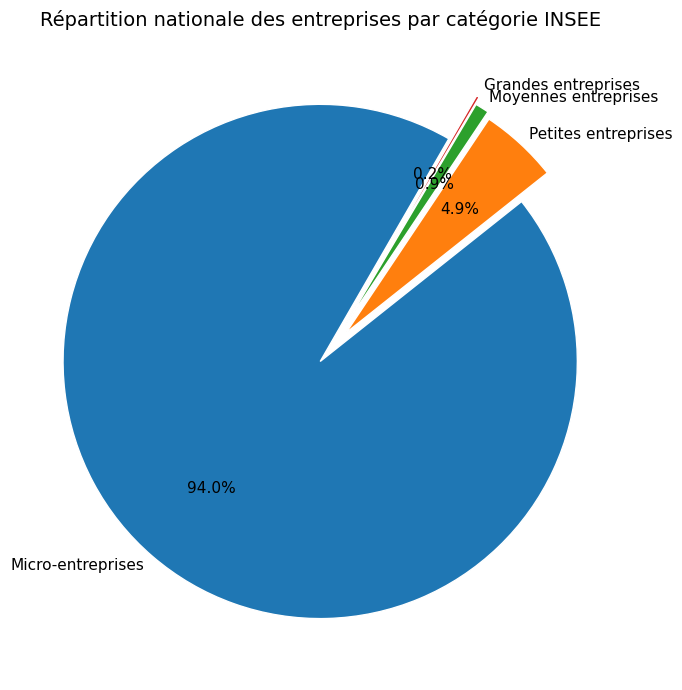

In [ ]:
# Colonnes du DataFrame
categories = [
    'Micro_E', 'Petites_E', 'Moyennes_E', 'Grandes_E'
]

# Libellés lisibles
labels = [
    "Micro-entreprises",
    "Petites entreprises",
    "Moyennes entreprises",
    "Grandes entreprises"
]

# Totaux
totaux = df_effectif[categories].sum()

# Détacher légèrement les parts
explode = [0.05, 0.10, 0.12, 0.15]

# Figure
fig, ax = plt.subplots(figsize=(7, 7))

# Camembert
wedges, texts, autotexts = ax.pie(
    totaux,
    labels=labels,              # ← texte directement sur les parts
    explode=explode,
    autopct='%1.1f%%',
    startangle=60,
    labeldistance=1.05,         # position des labels
    pctdistance=0.65,           # position des %
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white'}
)

# Titre
ax.set_title(
    "Répartition nationale des entreprises par catégorie INSEE",
    fontsize=14
)

ax.axis('equal')
plt.tight_layout()
plt.show()

/var/folders/7k/1gss3s8n3ks5v614tjxzcb2w0000gn/T/ipykernel_3931/227151172.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


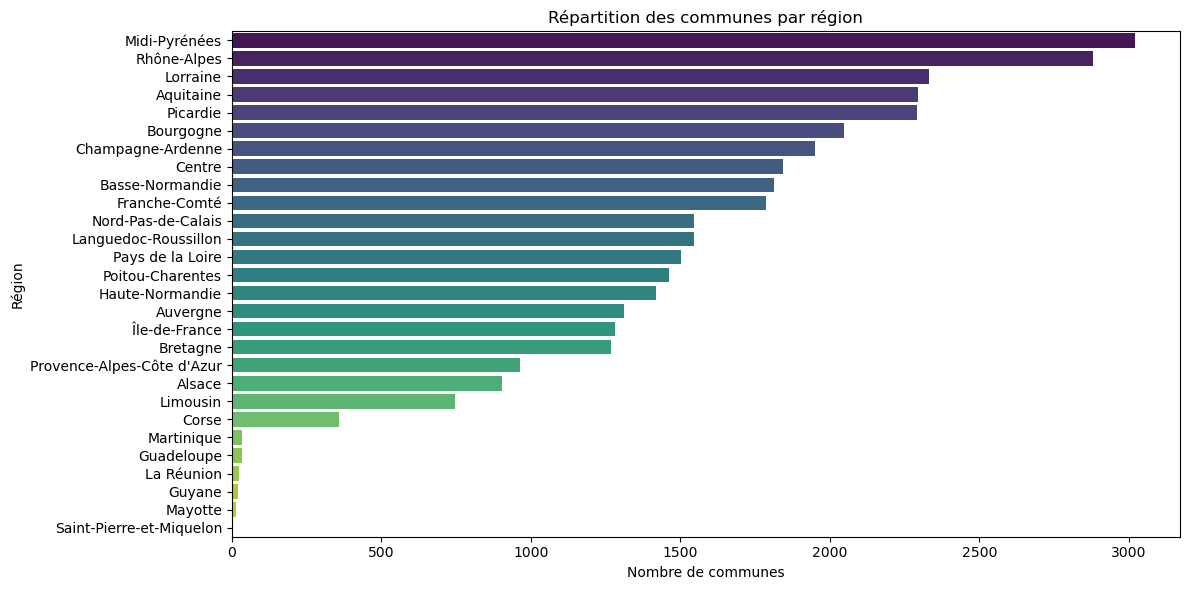

In [ ]:
communes_par_region = (
    df_geo.groupby(["code_région", "nom_région"])["CODGEO"]
       .nunique()
       .reset_index()
       .sort_values("CODGEO", ascending=False)
)

communes_par_region.columns = ["code_région", "nom_région", "Nombre_communes"]
communes_par_region

plt.figure(figsize=(12, 6))
sns.barplot(
    data=communes_par_region,
    x="Nombre_communes",
    y="nom_région",
    palette="viridis"
)
plt.title("Répartition des communes par région")
plt.xlabel("Nombre de communes")
plt.ylabel("Région")
plt.tight_layout()
plt.show()

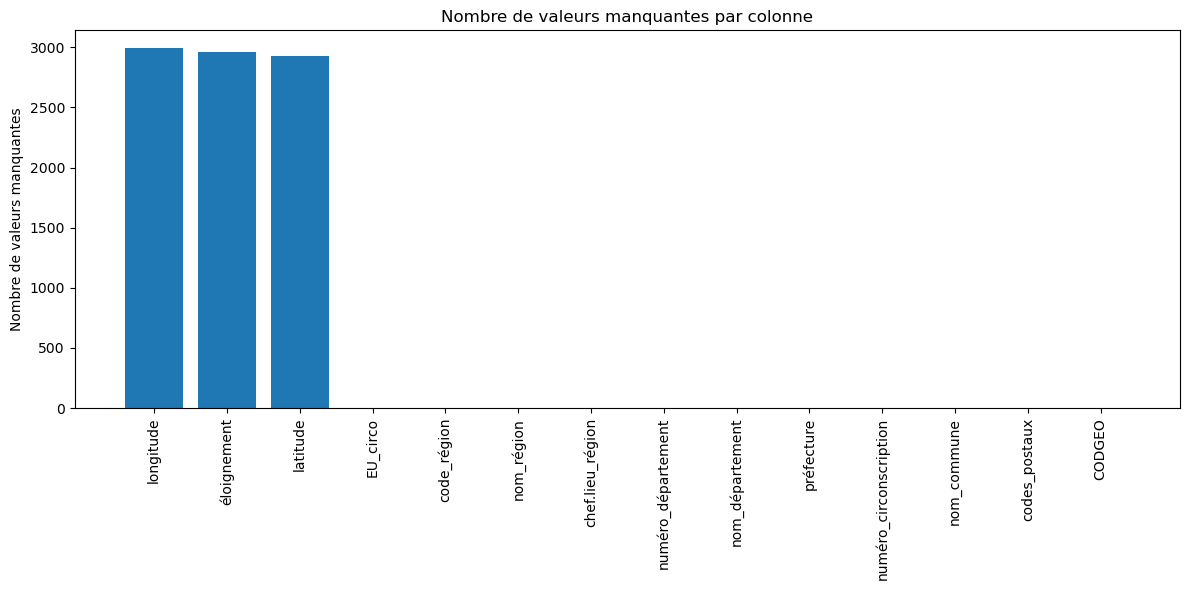

In [ ]:
valeurs_na = df_geo.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(valeurs_na.index, valeurs_na.values)
plt.title("Nombre de valeurs manquantes par colonne")
plt.ylabel("Nombre de valeurs manquantes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

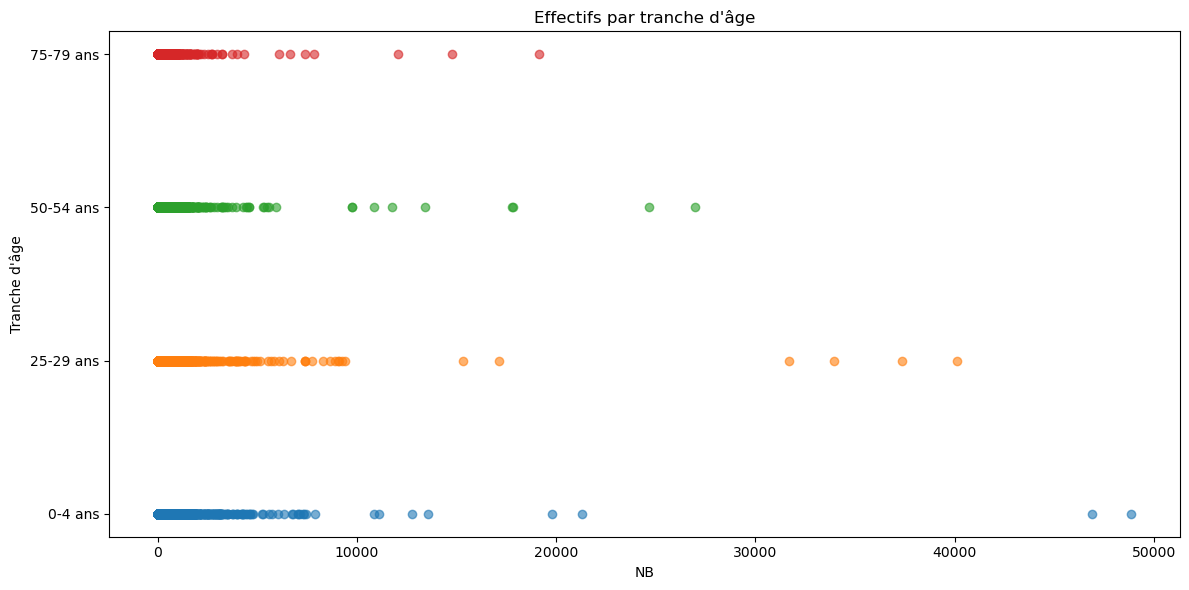

In [ ]:
tranches_age = ["0-4 ans", "25-29 ans", "50-54 ans", "75-79 ans"]

df_plot = df_population[df_population["TRANCHE_AGE"].isin(tranches_age)]

plt.figure(figsize=(12, 6))

for tranche in tranches_age:
    subset = df_plot[df_plot["TRANCHE_AGE"] == tranche]
    plt.scatter(
        subset["Nb_personnes_concernees"],
        [tranche] * len(subset),
        alpha=0.6
    )

plt.title("Effectifs par tranche d'âge")
plt.xlabel("NB")
plt.ylabel("Tranche d'âge")
plt.tight_layout()
plt.show()

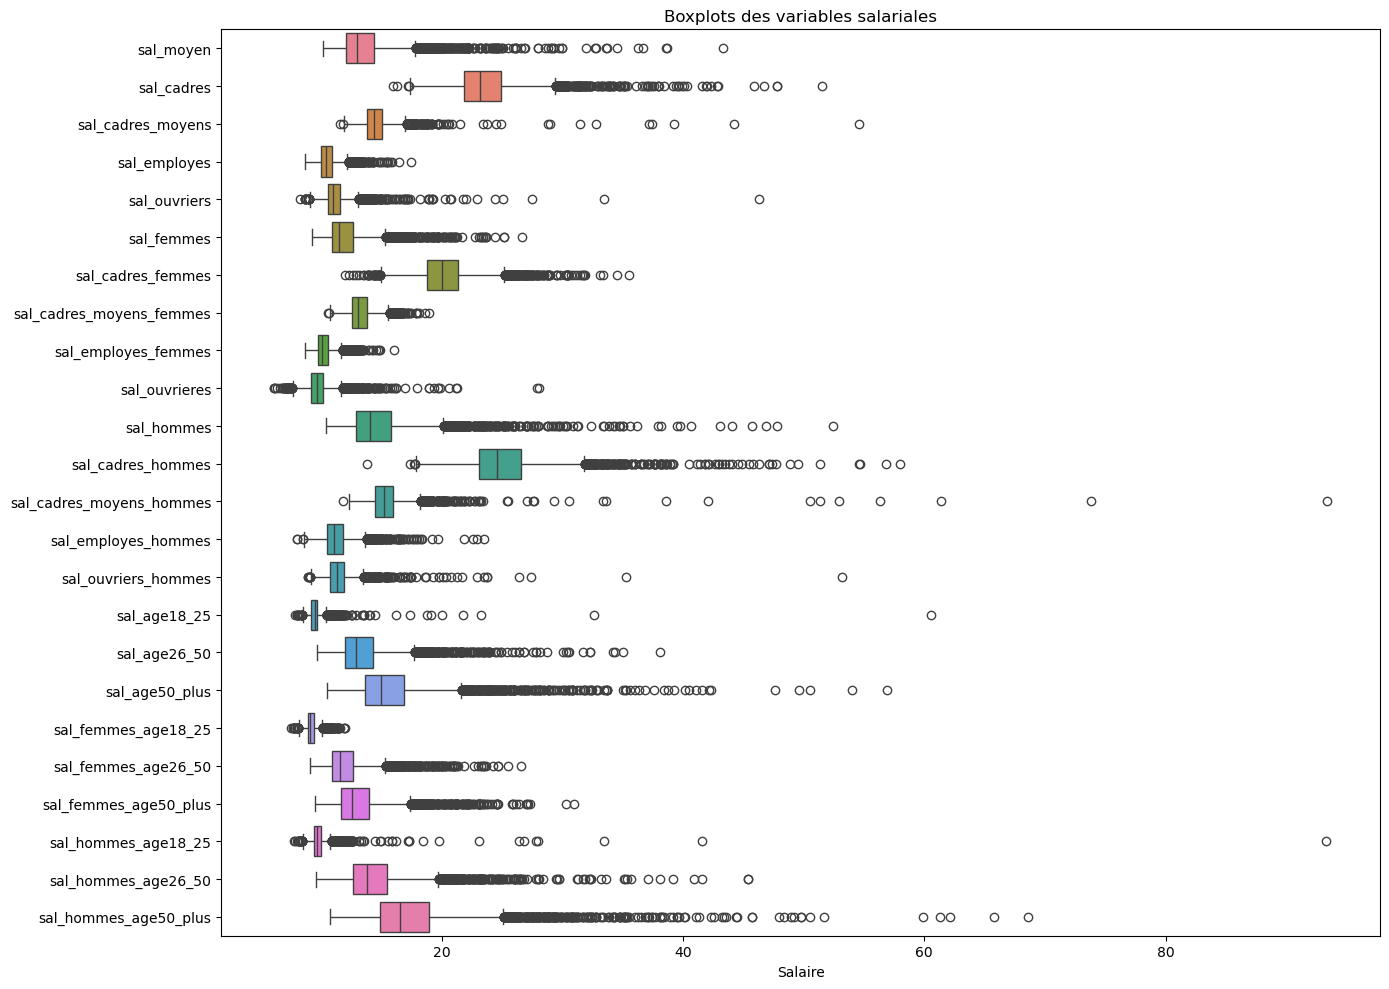

In [ ]:
salary_columns = [
    "sal_moyen",
    "sal_cadres",
    "sal_cadres_moyens",
    "sal_employes",
    "sal_ouvriers",
    "sal_femmes",
    "sal_cadres_femmes",
    "sal_cadres_moyens_femmes",
    "sal_employes_femmes",
    "sal_ouvrieres",
    "sal_hommes",
    "sal_cadres_hommes",
    "sal_cadres_moyens_hommes",
    "sal_employes_hommes",
    "sal_ouvriers_hommes",
    "sal_age18_25",
    "sal_age26_50",
    "sal_age50_plus",
    "sal_femmes_age18_25",
    "sal_femmes_age26_50",
    "sal_femmes_age50_plus",
    "sal_hommes_age18_25",
    "sal_hommes_age26_50",
    "sal_hommes_age50_plus"
]

salary_columns = [col for col in salary_columns if col in df_salary.columns]

plt.figure(figsize=(14, 10))
sns.boxplot(data=df_salary[salary_columns], orient="h")

plt.title("Boxplots des variables salariales")
plt.xlabel("Salaire")
plt.ylabel("")
plt.tight_layout()
plt.show()